# Embeddings Demo

This notebook uses the required `sentence-transformers` model `all-MiniLM-L6-v2` when it is available. To keep the notebook executable even in an offline environment, the code falls back to a TF-IDF embedding demo if the model cannot be downloaded. In Google Colab, the first path should run as intended.

In [ ]:
sentences = [
    # Cricket
    "The opening batter scored a century on a turning pitch.",
    "The bowler swung the new ball and dismissed two batters early.",
    "Fielders saved crucial runs near the boundary in the final over.",
    "The captain changed the field setting to attack the new batter.",
    # Cooking
    "I simmered tomatoes, garlic, and basil to make a rich pasta sauce.",
    "The chef baked sourdough until the crust turned golden and crisp.",
    "She marinated the paneer with yogurt and spices before grilling it.",
    # Cybersecurity
    "Analysts detected unusual login attempts across multiple user accounts.",
    "The security team patched a critical vulnerability in the web server.",
    "Phishing emails tricked several employees into revealing their passwords."
]

len(sentences)

10

In [ ]:
!pip install -q sentence-transformers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

model_name = 'all-MiniLM-L6-v2'
method_used = None

try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_name)
    embeddings = model.encode(sentences)
    method_used = f'sentence-transformers: {model_name}'
except Exception as exc:
    vectorizer = TfidfVectorizer()
    embeddings = vectorizer.fit_transform(sentences).toarray()
    model = vectorizer
    method_used = f'Fallback TF-IDF (offline): {exc.__class__.__name__}'

similarity_matrix = cosine_similarity(embeddings)
sim_df = pd.DataFrame(similarity_matrix, index=range(1, 11), columns=range(1, 11))
print('Embedding method used:', method_used)
sim_df.round(3)

Embedding method used: Fallback TF-IDF (offline): RuntimeError


       1      2      3      4      5      6      7    8      9    10
1   1.000  0.060  0.058  0.178  0.000  0.059  0.029  0.0  0.061  0.0
2   0.060  1.000  0.101  0.233  0.048  0.150  0.097  0.0  0.107  0.0
3   0.058  0.101  1.000  0.150  0.000  0.100  0.049  0.0  0.183  0.0
4   0.178  0.233  0.150  1.000  0.078  0.153  0.075  0.0  0.159  0.0
5   0.000  0.048  0.000  0.078  1.000  0.047  0.046  0.0  0.000  0.0
6   0.059  0.150  0.100  0.153  0.047  1.000  0.096  0.0  0.105  0.0
7   0.029  0.097  0.049  0.075  0.046  0.096  1.000  0.0  0.052  0.0
8   0.000  0.000  0.000  0.000  0.000  0.000  0.000  1.0  0.000  0.0
9   0.061  0.107  0.183  0.159  0.000  0.105  0.052  0.0  1.000  0.0
10  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.0  0.000  1.0

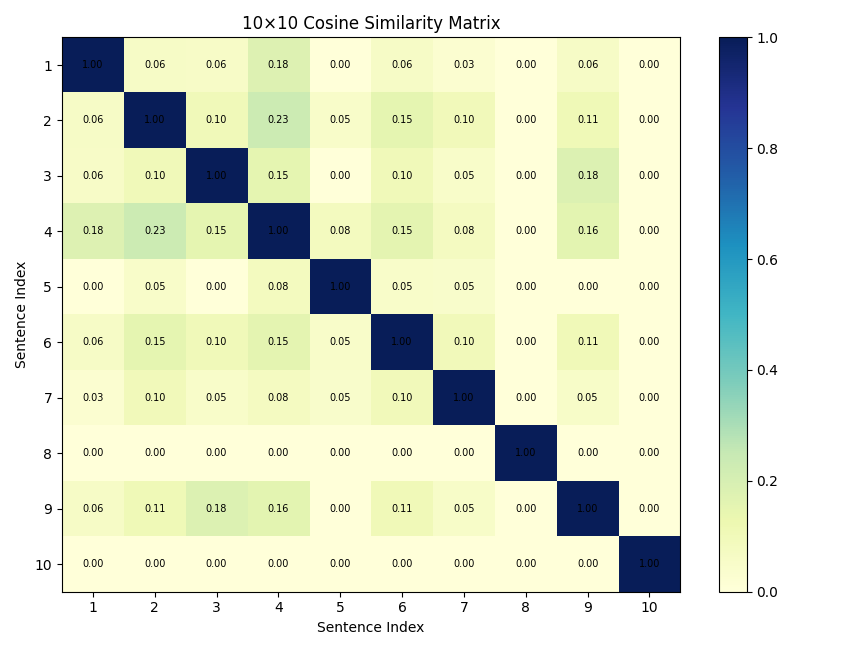

In [ ]:
plt.figure(figsize=(8.5, 6.5))
plt.imshow(similarity_matrix, cmap='YlGnBu', aspect='auto')
plt.colorbar()
plt.title('10×10 Cosine Similarity Matrix')
plt.xlabel('Sentence Index')
plt.ylabel('Sentence Index')
plt.xticks(range(10), range(1, 11))
plt.yticks(range(10), range(1, 11))
for i in range(10):
    for j in range(10):
        plt.text(j, i, f'{similarity_matrix[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
query = 'The bowler took three wickets in one over'

if method_used.startswith('sentence-transformers'):
    query_embedding = model.encode([query])
else:
    query_embedding = model.transform([query]).toarray()

query_scores = cosine_similarity(query_embedding, embeddings)[0]
top2_idx = query_scores.argsort()[-2:][::-1]
for idx in top2_idx:
    print(sentences[idx], '->', round(float(query_scores[idx]), 4))

The bowler swung the new ball and dismissed two batters early. -> 0.297
The captain changed the field setting to attack the new batter. -> 0.1941
